In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torchvision import datasets, transforms
import PIL
import torch.nn as nn
import pandas as pd
from torch.utils.data import DataLoader, random_split, Subset

In [24]:
train_data_dir = '../sign_lang_recognition/data/sign_mnist_train.csv'
test_data_dir = '../sign_lang_recognition/data/sign_mnist_test.csv'

In [25]:
class SignLanguageMNIST(torch.utils.data.Dataset):
    def __init__(self, csv_file, label_map, transform=None):
        self.data = pd.read_csv(csv_file)
        self.labels = self.data['label'].map(label_map).values
        # If not account for missing 2 classes
        # self.labels = self.data['label'].values
        
        # 784 pixel columns, so 28x28 with 1 channel (grayscale)
        pixels = self.data.drop('label', axis=1).values
        self.images = pixels.reshape(-1, 28, 28, 1).astype(np.uint8)
        
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

In [83]:
to_tensor = transforms.ToTensor()

train_df = pd.read_csv(train_data_dir)
label_map = {l: i for i, l in enumerate(sorted(train_df['label'].unique()))}

full_train_dataset = SignLanguageMNIST(
    csv_file=train_data_dir,
    label_map=label_map,
    transform=to_tensor
)

train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

train_subset, val_subset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

# only get the mean and standard for the train subset not validation subset to
# to avoid data leakage
train_imgs = torch.stack([img for img, _ in train_subset])
train_mean = train_imgs.mean()
train_std = train_imgs.std()

normalize = transforms.Normalize((train_mean,), (train_std,))
transform_norm = transforms.Compose([transforms.ToTensor(), normalize])

full_train_dataset_norm = SignLanguageMNIST(
    csv_file=train_data_dir,
    label_map=label_map,
    transform=transform_norm
)

train_tensor = Subset(full_train_dataset_norm, train_subset.indices)
val_tensor = Subset(full_train_dataset_norm, val_subset.indices)

test_tensor = SignLanguageMNIST(
    csv_file=test_data_dir,
    label_map=label_map,
    transform=transform_norm
)

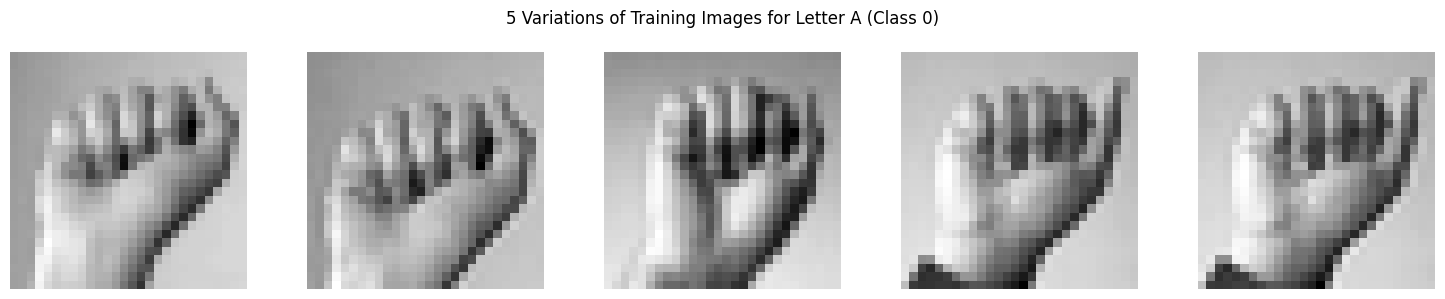

In [84]:
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
count = 0

for img, label in train_tensor:
    if label == 0:
        img_2d = img.squeeze()
        
        axes[count].imshow(img_2d, cmap='gray')
        axes[count].axis('off') 
        
        count += 1
        if count == 5:
            break

plt.suptitle("5 Variations of Training Images for Letter A (Class 0)")
plt.tight_layout()
plt.show()

To avoid data leakage, the test set must be normalized using the mean and standard deviation derived strictly from the training set. This ensures the model treats unseen data as it would in a real-world scenario. So trying an interation with the test data normalized using the train mean and standard deviation.

In [85]:
train_loader = DataLoader(train_subset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_tensor, batch_size=64, shuffle=False)

In [30]:
def train_model(n_epochs, model, optimizer, loss_fn, train_loader, val_loader):
    log_data = [] 
    
    for epoch in range(1, n_epochs + 1):
        model.train() 
        epoch_train_loss = 0.0
        train_correct, train_total = 0, 0
        for imgs, labels in train_loader:
            optimizer.zero_grad()
            preds = model(imgs)
            loss = loss_fn(preds, labels)
            loss.backward()
            optimizer.step()

            epoch_train_loss += loss.item()
            predicted = preds.argmax(dim=1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()

        model.eval() 
        epoch_val_loss = 0.0
        val_correct, val_total = 0, 0
        with torch.no_grad(): 
            for imgs, labels in val_loader: 
                preds = model(imgs)
                loss = loss_fn(preds, labels)
                epoch_val_loss += loss.item()
                predicted = preds.argmax(dim=1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        log_data.append({
            'epoch': epoch,
            'train_loss': epoch_train_loss / len(train_loader),
            'validation_loss': epoch_val_loss / len(val_loader),
            'train_accuracy': train_correct / train_total,
            'validation_accuracy': val_correct / val_total,
            'learning_rate': optimizer.param_groups[0]['lr']
        })
    return pd.DataFrame(log_data)

In [71]:
mlp_model_lr01 = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 256),
    nn.ReLU(),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Linear(128, 24)
)

adam_optimizer = torch.optim.Adam(mlp_model_lr01.parameters(), lr=0.01)

mlp_log_lr01 = train_model(n_epochs=15, 
                      optimizer=adam_optimizer,
                      loss_fn=nn.CrossEntropyLoss(),
                      model=mlp_model_lr01, 
                      train_loader=train_loader, 
                      val_loader=val_loader)

mlp_model_lr0001 = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 256),
    nn.ReLU(),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Linear(128, 24)
)

adam_optimizer = torch.optim.Adam(mlp_model_lr0001.parameters(), lr=0.0001)
mlp_log_lr0001 = train_model(n_epochs=15, 
                      optimizer=adam_optimizer,
                      loss_fn=nn.CrossEntropyLoss(),
                      model=mlp_model_lr0001, 
                      train_loader=train_loader, 
                      val_loader=val_loader)

mlp_model_lr001 = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 256),
    nn.ReLU(),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Linear(128, 24)
)

adam_optimizer = torch.optim.Adam(mlp_model_lr001.parameters(), lr=0.001)
mlp_log_lr001 = train_model(n_epochs=15, 
                      optimizer=adam_optimizer,
                      loss_fn=nn.CrossEntropyLoss(),
                      model=mlp_model_lr001, 
                      train_loader=train_loader, 
                      val_loader=val_loader)

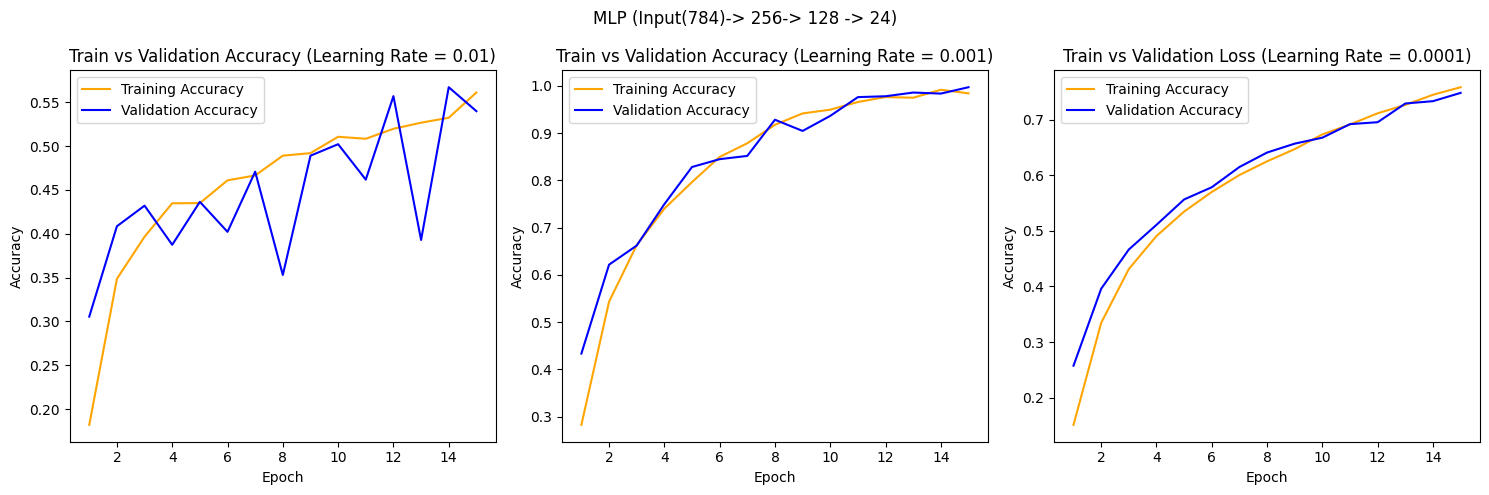

In [68]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
plt.suptitle("MLP (Input(784)-> 256-> 128 -> 24)")

axes[0].plot(mlp_log_lr01['epoch'], mlp_log_lr01['train_accuracy'], color='orange', label='Training Accuracy')
axes[0].plot(mlp_log_lr01['epoch'], mlp_log_lr01['validation_accuracy'], color='blue', label='Validation Accuracy')
axes[0].set_title('Train vs Validation Accuracy (Learning Rate = 0.01)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(mlp_log_lr001['epoch'], mlp_log_lr001['train_accuracy'], color='orange', label='Training Accuracy')
axes[1].plot(mlp_log_lr001['epoch'], mlp_log_lr001['validation_accuracy'], color='blue', label='Validation Accuracy')
axes[1].set_title('Train vs Validation Accuracy (Learning Rate = 0.001)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

axes[2].plot(mlp_log_lr0001['epoch'], mlp_log_lr0001['train_accuracy'], color='orange', label='Training Accuracy')
axes[2].plot(mlp_log_lr0001['epoch'], mlp_log_lr0001['validation_accuracy'], color='blue', label='Validation Accuracy')
axes[2].set_title('Train vs Validation Loss (Learning Rate = 0.0001)')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Accuracy')
axes[2].legend()

plt.tight_layout()
plt.show()


While the loss decreases overall for both the training and validation sets throughout the epochs,, the consistent fluctuations in the train and validation metrics suggest a slight optimization instability in the epochs, likely due to large parameter updates from the high learning rate. Although Adam adaptively scales learning rates for each parameter, the initial global learning rate still determines the overall step size, and if set too high, can lead to unstable updates and oscillations during training. To address this, the learning rate can be reduced to 0.0001 to smooth out fluctuations in loss and improve training stability.

As expected, reducing the learning rate from 0.01 to 0.0001 significantly improves the train and validation accuracy, as it approaches 0.75 for both at epoch 15, and leads to smoother accuracy curves. The accuracy of approximately 0.75 at epoch 15 indicates a sluggish rate of improvement, likely attributable to the relatively low learning rate. Tuning the learning rate to 0.001 shows to offer a better balance between rate of convergence and stability between the epochs.


In [62]:
mlp_model_deeper = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 448),
    nn.ReLU(),
    nn.Linear(448, 256),
    nn.ReLU(),
    nn.Linear(256, 140),
    nn.ReLU(),
    nn.Linear(140, 24)
)

deep_adam_optimizer = torch.optim.Adam(mlp_model_deeper.parameters(), lr=0.001)

mlp_log_large = train_model(n_epochs=15, 
                      optimizer=deep_adam_optimizer,
                      loss_fn=nn.CrossEntropyLoss(),
                      model=mlp_model_deeper, 
                      train_loader=train_loader, 
                      val_loader=val_loader)

mlp_model_small = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 256),
    nn.ReLU(),
    nn.Linear(256, 24)
)

shallow_adam_optimizer = torch.optim.Adam(mlp_model_small.parameters(), lr=0.001)

mlp_log_small = train_model(n_epochs=15, 
                      optimizer=shallow_adam_optimizer,
                      loss_fn=nn.CrossEntropyLoss(),
                      model=mlp_model_small, 
                      train_loader=train_loader, 
                      val_loader=val_loader)

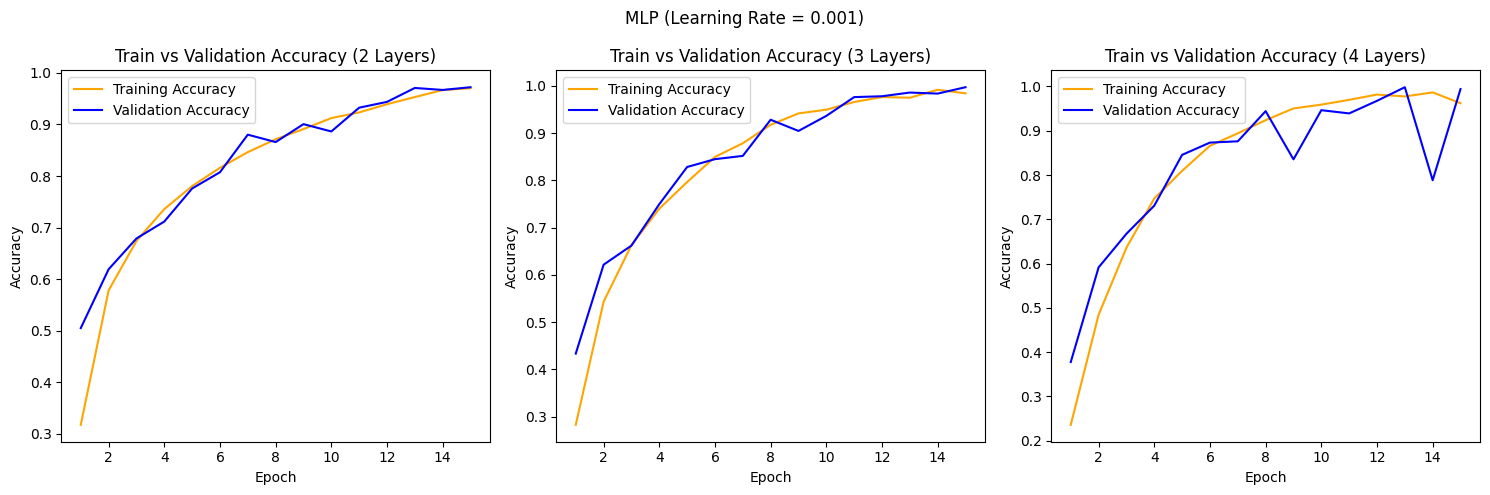

In [67]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
plt.suptitle("MLP (Learning Rate = 0.001)")

axes[0].plot(mlp_log_small['epoch'], mlp_log_small['train_accuracy'], color='orange', label='Training Accuracy')
axes[0].plot(mlp_log_small['epoch'], mlp_log_small['validation_accuracy'], color='blue', label='Validation Accuracy')
axes[0].set_title('Train vs Validation Accuracy (2 Layers)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(mlp_log_lr001['epoch'], mlp_log_lr001['train_accuracy'], color='orange', label='Training Accuracy')
axes[1].plot(mlp_log_lr001['epoch'], mlp_log_lr001['validation_accuracy'], color='blue', label='Validation Accuracy')
axes[1].set_title('Train vs Validation Accuracy (3 Layers)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

axes[2].plot(mlp_log_large['epoch'], mlp_log_large['train_accuracy'], color='orange', label='Training Accuracy')
axes[2].plot(mlp_log_large['epoch'], mlp_log_large['validation_accuracy'], color='blue', label='Validation Accuracy')
axes[2].set_title('Train vs Validation Accuracy (4 Layers)')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Accuracy')
axes[2].legend()

plt.tight_layout()
plt.show()

Based on the results, it seems like a smaller network with just two layers have a similar performance. Would drop out impact performance or could it be another potential way to avoid overfitting?

In [65]:
p_values = [0.1, 0.2, 0.3, 0.4, 0.5]
grid_search_results = []

for p in p_values:
    current_model = nn.Sequential(
        nn.Flatten(),                 
        nn.Linear(784, 256),        
        nn.ReLU(),
        nn.Dropout(p=p),
        nn.Linear(256, 24)            
    )
    current_optimizer = torch.optim.Adam(current_model.parameters(), lr=0.001)
    
    log_df = train_model(n_epochs=15, 
                         model=current_model, 
                         optimizer=current_optimizer,
                         loss_fn=nn.CrossEntropyLoss(),
                         train_loader=train_loader, 
                         val_loader=val_loader)
    
    final_train_acc = log_df['train_accuracy'].iloc[-1]
    final_val_acc = log_df['validation_accuracy'].iloc[-1]
    
    grid_search_results.append({
        'p_value': p,
        'final_train_accuracy': final_train_acc,
        'final_validation_accuracy': final_val_acc
    })

results_df = pd.DataFrame(grid_search_results)
best_results = results_df.sort_values(by='final_validation_accuracy', ascending=False)

print("\n=== Grid Search Results ===")
print(best_results)


=== Grid Search Results ===
   p_value  final_train_accuracy  final_validation_accuracy
0      0.1              0.921736                   0.969222
2      0.3              0.831360                   0.941359
1      0.2              0.782826                   0.895101
3      0.4              0.723229                   0.866327
4      0.5              0.614779                   0.822072


In [90]:
def test_model(model, test_loader):
  model.eval()

  test_correct, test_total = 0, 0
  with torch.no_grad(): 
    for imgs, labels in test_loader: 
        preds = model(imgs)
        predicted = preds.argmax(dim=1)
        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()

  accuracy = test_correct / test_total
  print("Test Accuracy:", accuracy)
  return accuracy

In [92]:
best_model_test_acc = test_model(mlp_model_lr001, test_loader)

Test Accuracy: 0.5416899051868377
